<a href="https://colab.research.google.com/github/Martinmbiro/standard-autoencoder/blob/main/01.%20Standard%20AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coding a standard AutoEncoder
This notebook entails coding a standard autoencoder, training it and analysing the results
+ I begin by configuring the system environment, and loading a 5,000-image subset of the MNIST dataset.
+ The model's architecture relies on simple fully-connected [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers
+ The encoder network compresses the 784-pixel flattened images into a 128-dimensional latent space, and the decoder network that reconstructs the images using [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html) and [`nn.Sigmoid`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) activation functions.

### Getting started
> Here, we install necessary libraries, import relevant modules and download the EMNIST dataset

In [ ]:
# install pytorch lightning, torchinfo
!pip install -q lightning torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 970.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.4/848.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 46.6 MB/s eta 0:00:00


In [ ]:
# imports
import torch, torch.nn as nn
import torchvision.transforms.v2 as T
import torch.optim as optim

from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from torchinfo import summary

import matplotlib.pyplot as plt, numpy as np, pandas as pd
import plotly.express as px
import os

from pathlib import Path

In [ ]:
# define device
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

# display device
print(device)

cpu


#### Downloading the MNIST dataset
> Here, we download the dataset and apply transforms

In [ ]:
# define image transforms
img_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(dtype=torch.float32, scale=True)
])

# download MNIST dataset
data = datasets.MNIST(
    root='mnist_data', train=True, download=True, transform=img_transforms
)

# create a subset of the dataset
# (purely for faster training, since I was using slower free GPU)
data = Subset(dataset=data,
              indices=torch.randint(0, len(data), (5000,)))


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 628kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.51MB/s]


In [ ]:
# display size of dataset
print(f'Size of dataset: {len(data)}')

Size of dataset: 5000


#### Creating `DataLoader` from data
> The `DataLoader` helps us pass data to the model during training operations

In [ ]:
# define batch size
BATCH_SIZE = 128

# data loader
train_loader = DataLoader(
    dataset=data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=os.cpu_count(),
    pin_memory=True
)

### Coding the AutoEncoder
+ Here, we'll have the network constitute of [`nn.Linear`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.Linear.html#torch.nn.Linear) layers

In [ ]:
LATENT_DIM, HIDDEN_DIM = 128, 256

class AutoEncoder(nn.Module):
  def __init__(self, latent_dim:int, hidden_dim:int=HIDDEN_DIM):
    super().__init__()
    # encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU(),
    )

    # decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )

  def forward(self, x):
    # convert to latent space
    z = self.encoder(x)

    # decode to reconstruct
    x_recon = self.decoder(z)

    return x_recon

In [ ]:
torch.manual_seed(789)

# initialize model
auto_encoder = AutoEncoder(latent_dim=LATENT_DIM)

#### Untrained AutoEncoder inference
Here, we perform inference using the AutoEncoder in its untrained state, to compare the results later


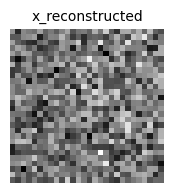

In [ ]:
x, _ = data[np.random.randint(0, len(data))]
x = x.to(device)
auto_encoder.to(device)

with torch.inference_mode():
  auto_encoder.eval()
  pred = auto_encoder(x.view(-1, 784))
  pred = pred.view(-1, 28, 28)

plt.figure(figsize=(2, 2))
plt.title("x_reconstructed", fontsize=10)
plt.imshow(pred.cpu().permute(1,2,0), cmap='gray')
plt.axis(False)
plt.show()

📝 **Note**  
+ As expected, the model outputs gibberish since the weights and biases have not been optimized yet

#### Visualizing AutoEncoder summary
> Here, we use `torchinfo.summary` to visualize a summary of the model's layers, and tensor output shapes

In [ ]:
# sample input (with batch dimension)
sample_input = torch.randn(1, 1, 28, 28)

# visualize model summary
summary(auto_encoder, input_data=sample_input.view(-1, 784).to(device))

Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [1, 784]                  --
├─Sequential: 1-1                        [1, 128]                  --
│    └─Linear: 2-1                       [1, 256]                  200,960
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Linear: 2-3                       [1, 128]                  32,896
│    └─ReLU: 2-4                         [1, 128]                  --
├─Sequential: 1-2                        [1, 784]                  --
│    └─Linear: 2-5                       [1, 256]                  33,024
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 784]                  201,488
│    └─Sigmoid: 2-8                      [1, 784]                  --
Total params: 468,368
Trainable params: 468,368
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.47
Input size (MB): 0.00
For

### Set up Pytorch Lightning
> Pytorch lightning provides a high-level interface for PyTorch training and scaling

In [ ]:
# imports
import lightning as L

#### Add a [`LightningModule`](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html)
The LightningModule is the full recipe that defines how your `nn.Modules` interact.
+ The [`training_step`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.training_step) defines how the `nn.Module`(s) interact together.
+ In the [`configure_optimizers`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.configure_optimizers) define the optimizer(s) for your models.

In [ ]:
class LitModule(L.LightningModule):
  def __init__(self, model:nn.Module):
    super().__init__()
    self.model = model
    self.loss_fn = nn.MSELoss()

  # training_step defines the train loop
  def training_step(self, batch, batch_idx):
    x, _ = batch
    x = x.view(-1, 784)

    # forward pass
    x_recon = self.model(x)

    # calculate loss
    loss = self.loss_fn(x_recon, x)
    # log loss
    self.log('mse_loss', loss,
             prog_bar=True,
             # aggregate at the end of every epoch:
             on_epoch=True,
             on_step=False,
             batch_size=len(x))

    return loss

  # define and return optimizer
  def configure_optimizers(self):
    optimizer = optim.Adam(params=self.parameters(), lr=1e-3)
    return optimizer

#### Set up [`EarlyStopping`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.EarlyStopping.html#earlystopping) and [`ModelCheckpoint`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.ModelCheckpoint.html#modelcheckpoint)
+ `EarlyStopping` - Monitors a metric and stop training when it stops improving
+ `ModelCheckpoint` - Save the model after every epoch by monitoring a quantity

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='mse_loss',
    mode='min',
    min_delta=1e-3,
    patience=3
)

# ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    dirpath=Path.cwd().joinpath('checkpoints'),
    monitor='mse_loss',
    mode='min'
)

### Train the model
> Once the PyTorch code has been organized in a `LightningModule`, the [`Trainer`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.trainer.trainer.Trainer.html) automates the core engineering and infrastructure details of training deep learning models
+ It also enables logging using `loggers` such as the [`CSVLogger`](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.CSVLogger.html#lightning.pytorch.loggers.CSVLogger)

In [ ]:
from lightning.pytorch.loggers import CSVLogger

# path to save csv file
csv_logger = CSVLogger(Path.cwd().joinpath('train_logs'))

In [ ]:
%%time
lit_module = LitModule(model=auto_encoder)

trainer = L.Trainer(
    logger=csv_logger,
    max_epochs=20,
    enable_model_summary=False,
    callbacks = [model_checkpoint]
  )

trainer.fit(
    model=lit_module,
    train_dataloaders=data
  )

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


CPU times: user 22min 10s, sys: 1min 2s, total: 23min 12s
Wall time: 26min 19s


#### Load model from `Modelcheckpoint`
Here, we load the best trained model from the checkpoint saved by the `ModelCheckpoint` callback
+ To do this, we call [`load_from_checkpoint`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.load_from_checkpoint)

⚠ **Note**
+ Note that this method is a class method, hence one should use the custom `LightningModule` class to call it
+ Any methods passed to the class' constructor (`__init__`) method are also passed here

In [ ]:
# load from checkpoint
from_checkpoint = LitModule.load_from_checkpoint(
    # checkpoint_path=model_checkpoint.best_model_path,
    checkpoint_path='/content/epoch=19-step=100000.ckpt',
    map_location=device,
    model=auto_encoder # argument passed to __init__ of the LightningModule class
)

# assign variable to model from checkpoint
auto_encoder = from_checkpoint.model

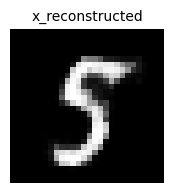

In [ ]:
# run inference using random input
x, _ = data[np.random.randint(0, len(data))]
x = x.to(device)
auto_encoder.to(device)
auto_encoder.eval()

with torch.inference_mode():
  pred = auto_encoder(x.view(-1, 784))
  pred = pred.view(-1, 28, 28)

plt.figure(figsize=(2, 2))
plt.title('x_reconstructed', fontsize=10)
plt.imshow(pred.cpu().permute(1,2,0), cmap='gray')
plt.axis(False)
plt.show()

🎆🎊 Seems like we have successfully loaded the right model!

#### Plot training loss across epochs
The `CSVLogger` object creates a `*.csv` file in a directory of choice.
+ Hence, we can read this file using `pandas` and plot the `mse_loss` that we logged during training

In [ ]:
# read the csv containing logs into a DataFrame
# df = pd.read_csv('/content/train_logs/lightning_logs/version_0/metrics.csv')
df = pd.read_csv('/content/metrics.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   epoch     20 non-null     int64  
 1   mse_loss  20 non-null     float64
 2   step      20 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 612.0 bytes


In [ ]:
# display DataFrame
df

,epoch,mse_loss,step
0,0,0.029435,4999
1,1,0.021477,9999
2,2,0.018464,14999
3,3,0.016709,19999
4,4,0.015681,24999
5,5,0.014981,29999
6,6,0.014508,34999
7,7,0.014040,39999
8,8,0.013676,44999
9,9,0.013352,49999


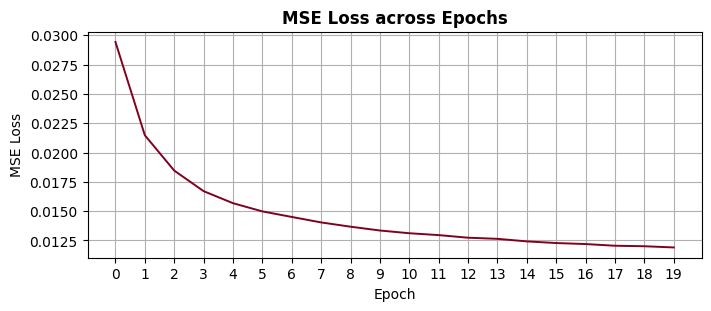

In [ ]:
# plot MSE Loss vs Epoch
f, ax = plt.subplots(figsize=(7,3), layout='compressed')

ax.plot(df['mse_loss'], linewidth=1.4, color='#800020')

ax.set_title('MSE Loss across Epochs', weight='black')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')

ax.xaxis.set_ticks(df['epoch'])
ax.grid()
plt.show()

#### Ground truth vs reconstructed input
> Here, we plot the ground truth images against reconstructed images

In [ ]:
# set model to eval, move to device
auto_encoder.eval()
auto_encoder.to(device);

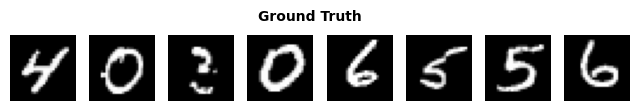

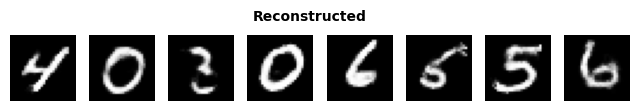

In [ ]:
# generate random indices from dataset
rand_indices = torch.randint(0, len(data), (8,))

# plot ground truths (x):
f, axs = plt.subplots(1, 8, figsize=(8,2))
for i, ax in zip(rand_indices, axs.flat):
  x, _ = data[i]
  ax.imshow(x.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Ground Truth', y=0.79, fontsize=10, weight='black')

# plot x_reconstructed:
f, axs = plt.subplots(1, 8, figsize=(8,2))
for i, ax in zip(rand_indices, axs.flat):
  with torch.inference_mode():
    x, _ = data[i]
    x = x.to(device)
    x_recon = auto_encoder(x.view(-1, 784))
    x_recon = x_recon.view(-1, 28, 28).cpu()

  ax.imshow(x_recon.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Reconstructed', y=0.79, fontsize=10, weight='black')

plt.show()

### Visualizing the latent space
Since the latent dimension is 128, it's hard to visualize it as it is.
+ Hence, we shall make use of [`sklearn`](http://scikit-learn.org/) Principal Component Analysis (PCA) to bin down the 128 dimensions into 2 and 3 dimensions for plotting

In [ ]:
# set model to eval, move to device
auto_encoder.eval()
auto_encoder.to(device);

In [ ]:
# empty lists
latents, labels = [], []

with torch.inference_mode():
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = auto_encoder.encoder(x)

    latents.append(z)
    labels.append(y)

  # concatenate the tensors inside the lists, row-wise
  latents = torch.cat(latents, dim=0)
  labels = torch.cat(labels, dim=0)

In [ ]:
# shape of tensors produced:
latents.shape, labels.shape

(torch.Size([4992, 128]), torch.Size([4992]))

In [ ]:
from sklearn.decomposition import PCA

# ininialize PCA objects: 2D, 3D
pca2, pca3 = PCA(n_components=2), PCA(n_components=3)

# perform PCA on the latent dim to produce 2D & 3D features
Z_pca2 = pca2.fit_transform(latents.detach().cpu().numpy()) # 2D
Z_pca3 = pca3.fit_transform(latents.detach().cpu().numpy()) # 3D

#### In 2D

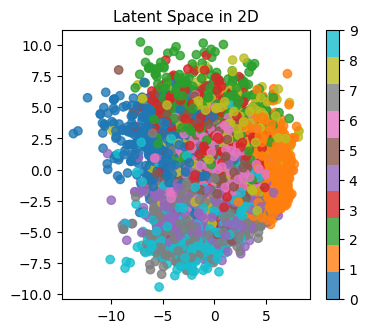

In [ ]:
# create Figure, Axes
plt.figure(figsize=(4,3.5))
plt.title('Latent Space in 2D', fontsize=11)
sc = plt.scatter(Z_pca2[:, 0], Z_pca2[:, 1],
                 c=labels, cmap='tab10', alpha=0.8)

plt.colorbar(sc)
plt.show()

#### In 3D

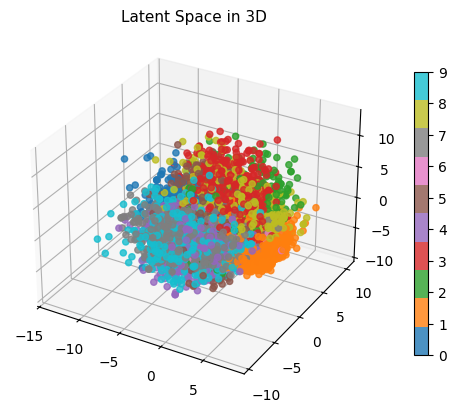

In [ ]:
# -----matplotlib--------
# create Figure, Axes
f, ax = plt.subplots(figsize=(4.5,4.5), layout='constrained',
                     subplot_kw={'projection': '3d'})

scat = ax.scatter(Z_pca3[:, 0], Z_pca3[:, 1], Z_pca3[:, 2],
                  c=labels, cmap='tab10', alpha=0.8)
ax.set_title('Latent Space in 3D', fontsize=11)

f.colorbar(scat, ax=ax, pad=0.1, shrink=0.65)
plt.show()

In [ ]:
# ----plotly------------
# defining a plotly scatter_3d plot:
f = px.scatter_3d(
    x=Z_pca3[:,0], y=Z_pca3[:,1], z=Z_pca3[:,2],
    color=labels, opacity=0.9, color_continuous_scale='inferno'
  )
f.update_traces(marker=dict(size=5))
f.show()

### Sampling a random vector from latent space
> Here, we'll sample random vectors from the latent space, and decode these vectors and plot the result

In [ ]:
# set model to eval, move to device
auto_encoder.eval()
auto_encoder.to(device)

# instantiate ReLU object
relu = nn.ReLU()

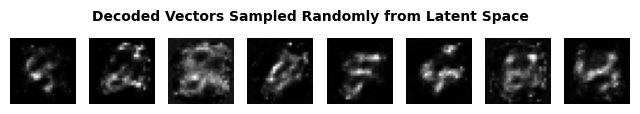

In [ ]:
f, axs = plt.subplots(1, 8, figsize=(8, 3))

with torch.inference_mode():
  z_rands = torch.randn(8, 1, LATENT_DIM)
  for z, ax in zip(z_rands.unbind(), axs.flat):
    z = relu(z)
    recon = auto_encoder.decoder(z.to(device))
    recon = recon.view(1, 28, 28).cpu()
    ax.imshow(recon.permute(1,2,0), cmap='gray')
    ax.axis(False)

  f.suptitle('Decoded Vectors Sampled Randomly from Latent Space',
             y=0.7, fontsize=10, weight='black')
  plt.show()

🔔 **Note**  
Sampling from the latent space reveals the major shortcoming of the standard AutoEncoder: the encoder maps each training input to a single point in latent space - not a region / distribution; just one precise coordinate. This means:
+ The neural network only ever sees and trains those exact points
+ The clusters could be anywhere, at any scale
+ The decoder has never been trained on what to do with spaces between clusters
+ If you sample a random point in latent space and decode it, you'll most probably get gibberish

📝 **Hence**  
> The standard AutoEncoder can compress and reconstruct, but the latent space has no structure one can sample from or navigate reliably - this will be fixed with a Variational AutoEncoder (VAE), in an upcoming repository